## <span style="color:#4ea8de">Modelo de Regresión Logística</span>
#### <span style="color:#4ea8de">Lectura de archivo</span>

In [ ]:
# Importación de librerías y carga de archivo

import pandas as pd
df= pd.read_csv('general_data_.csv')
df.sample(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
3733,44,No,Travel_Frequently,Research & Development,5,3,Life Sciences,1,3734,Female,...,7.0,Y,16,8,2,11.0,2,1,0,0
3895,23,Yes,Travel_Rarely,Research & Development,12,2,Medical,1,3896,Male,...,1.0,Y,14,8,2,3.0,2,3,0,2
987,24,No,Travel_Frequently,Sales,3,4,Marketing,1,988,Male,...,0.0,Y,11,8,1,3.0,5,2,2,1
2293,35,No,Travel_Rarely,Research & Development,23,4,Life Sciences,1,2294,Male,...,1.0,Y,14,8,0,11.0,2,11,3,3
686,28,No,Non-Travel,Research & Development,1,3,Medical,1,687,Male,...,0.0,Y,13,8,0,10.0,2,9,7,5
2533,47,No,Travel_Rarely,Sales,2,2,Life Sciences,1,2534,Female,...,4.0,Y,14,8,1,7.0,3,2,2,0
4050,34,No,Travel_Frequently,Research & Development,9,4,Life Sciences,1,4051,Female,...,1.0,Y,12,8,3,16.0,4,15,6,11
3713,46,Yes,Travel_Rarely,Research & Development,18,1,Medical,1,3714,Male,...,4.0,Y,11,8,1,28.0,2,7,4,3
3866,54,No,Travel_Rarely,Sales,24,3,Marketing,1,3867,Male,...,3.0,Y,14,8,0,36.0,5,10,4,7
360,25,No,Travel_Rarely,Research & Development,17,3,Medical,1,361,Male,...,7.0,Y,11,8,3,6.0,5,4,0,1


#### <span style="color:#4ea8de">Exploración de datos y Feature Engineering</span>

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [ ]:
# Estadística
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [148]:
df.shape

(4410, 24)

In [2]:
# Suma de valores nulos en el dataset
print('Valores nulos: ', df.isnull().sum().sum())

Valores nulos:  28


In [19]:
# Columnas con valores nulos
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [5]:
# Correlación de variables numéricas
corr_df= df.corr(numeric_only= True)

In [6]:
corr_df

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.006963,-0.035706,NaN,0.008649,-0.002884,-0.044314,0.299243,-0.033137,NaN,-0.031753,0.680661,-0.027308,0.311309,0.216513,0.202089
DistanceFromHome,0.006963,1.000000,-0.008638,NaN,-0.001097,-0.037329,-0.021607,-0.013843,0.038125,NaN,0.011169,0.009374,-0.009001,0.031684,0.002290,0.021584
Education,-0.035706,-0.008638,1.000000,NaN,-0.009680,0.045746,0.006410,-0.016250,-0.040531,NaN,0.001261,-0.010717,0.010472,0.006080,0.022490,0.005358
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeID,0.008649,-0.001097,-0.009680,NaN,1.000000,-0.003303,0.007338,-0.001117,-0.004456,NaN,-0.014254,-0.001063,-0.010191,0.004086,0.000256,0.008579
JobLevel,-0.002884,-0.037329,0.045746,NaN,-0.003303,1.000000,0.047316,-0.009875,0.010973,NaN,0.000993,-0.036957,-0.032500,-0.064219,-0.060811,-0.055251
MonthlyIncome,-0.044314,-0.021607,0.006410,NaN,0.007338,0.047316,1.000000,-0.020726,0.004325,NaN,0.026930,-0.033787,0.050112,0.000995,0.065219,0.024304
NumCompaniesWorked,0.299243,-0.013843,-0.016250,NaN,-0.001117,-0.009875,-0.020726,1.000000,0.030860,NaN,0.017163,0.238807,-0.032286,-0.117959,-0.036656,-0.109667
PercentSalaryHike,-0.033137,0.038125,-0.040531,NaN,-0.004456,0.010973,0.004325,0.030860,1.000000,NaN,0.012548,-0.018736,-0.037392,-0.029707,-0.029542,-0.040864
StandardHours,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Importación de librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

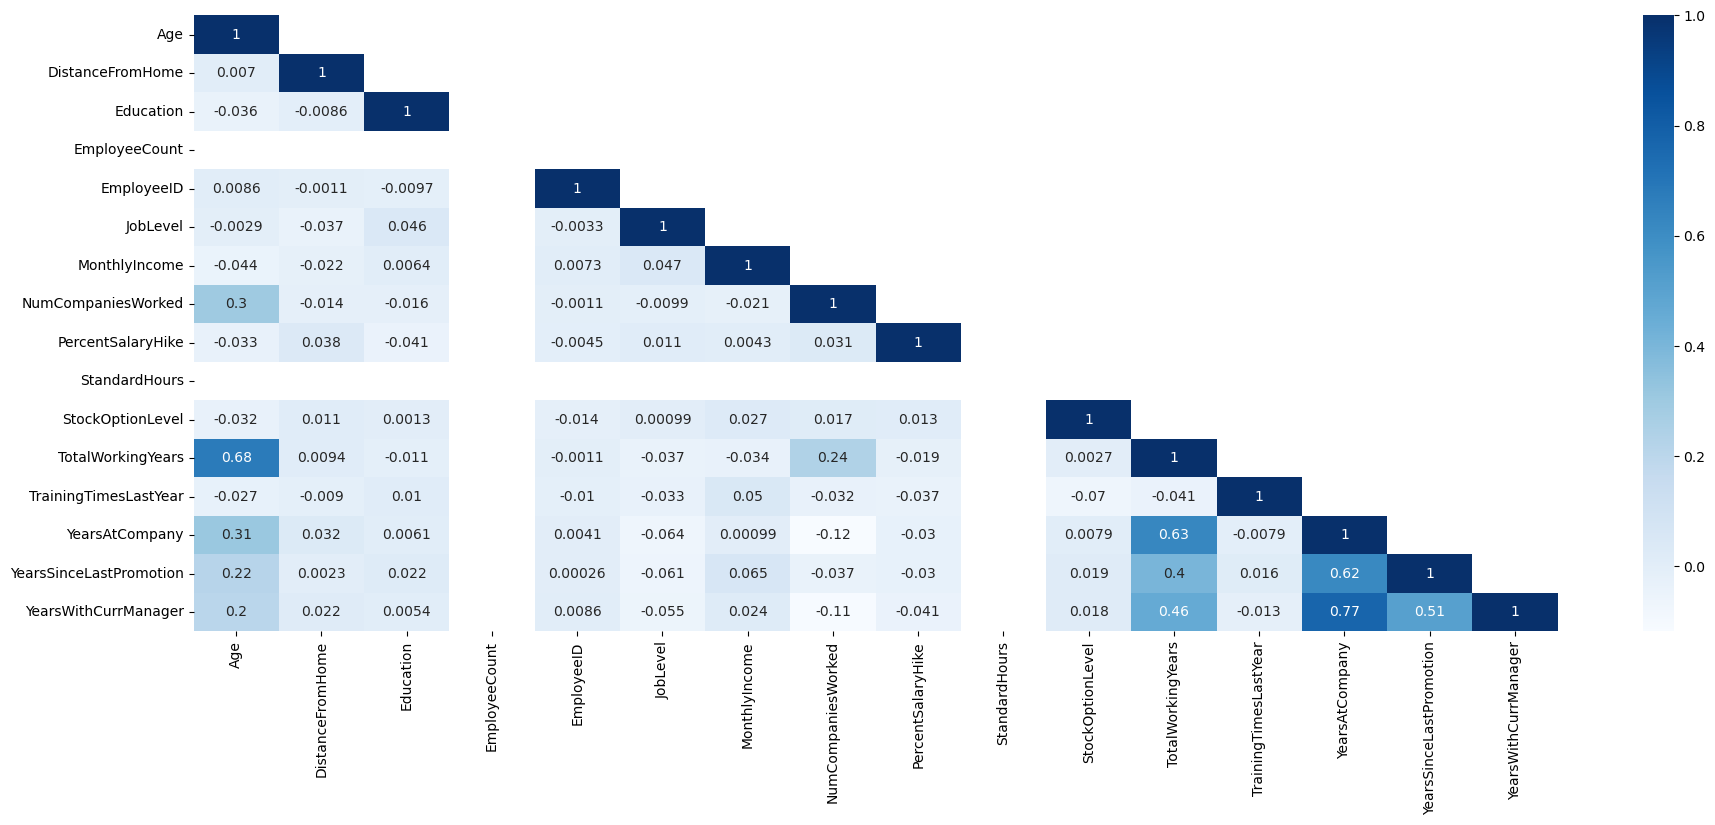

In [ ]:
# Matriz de correlación de variables
import numpy as np
plt.subplots(figsize= (22, 8))
df_map= corr_df.where(np.tril(np.ones(corr_df.shape).astype(bool)))
sns.heatmap(df_map, cmap= 'Blues', annot= True)

In [ ]:
# Columnas numéricas
numeric_cols= df.select_dtypes(exclude= 'object').columns
numeric_cols

Index(['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID',
       'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

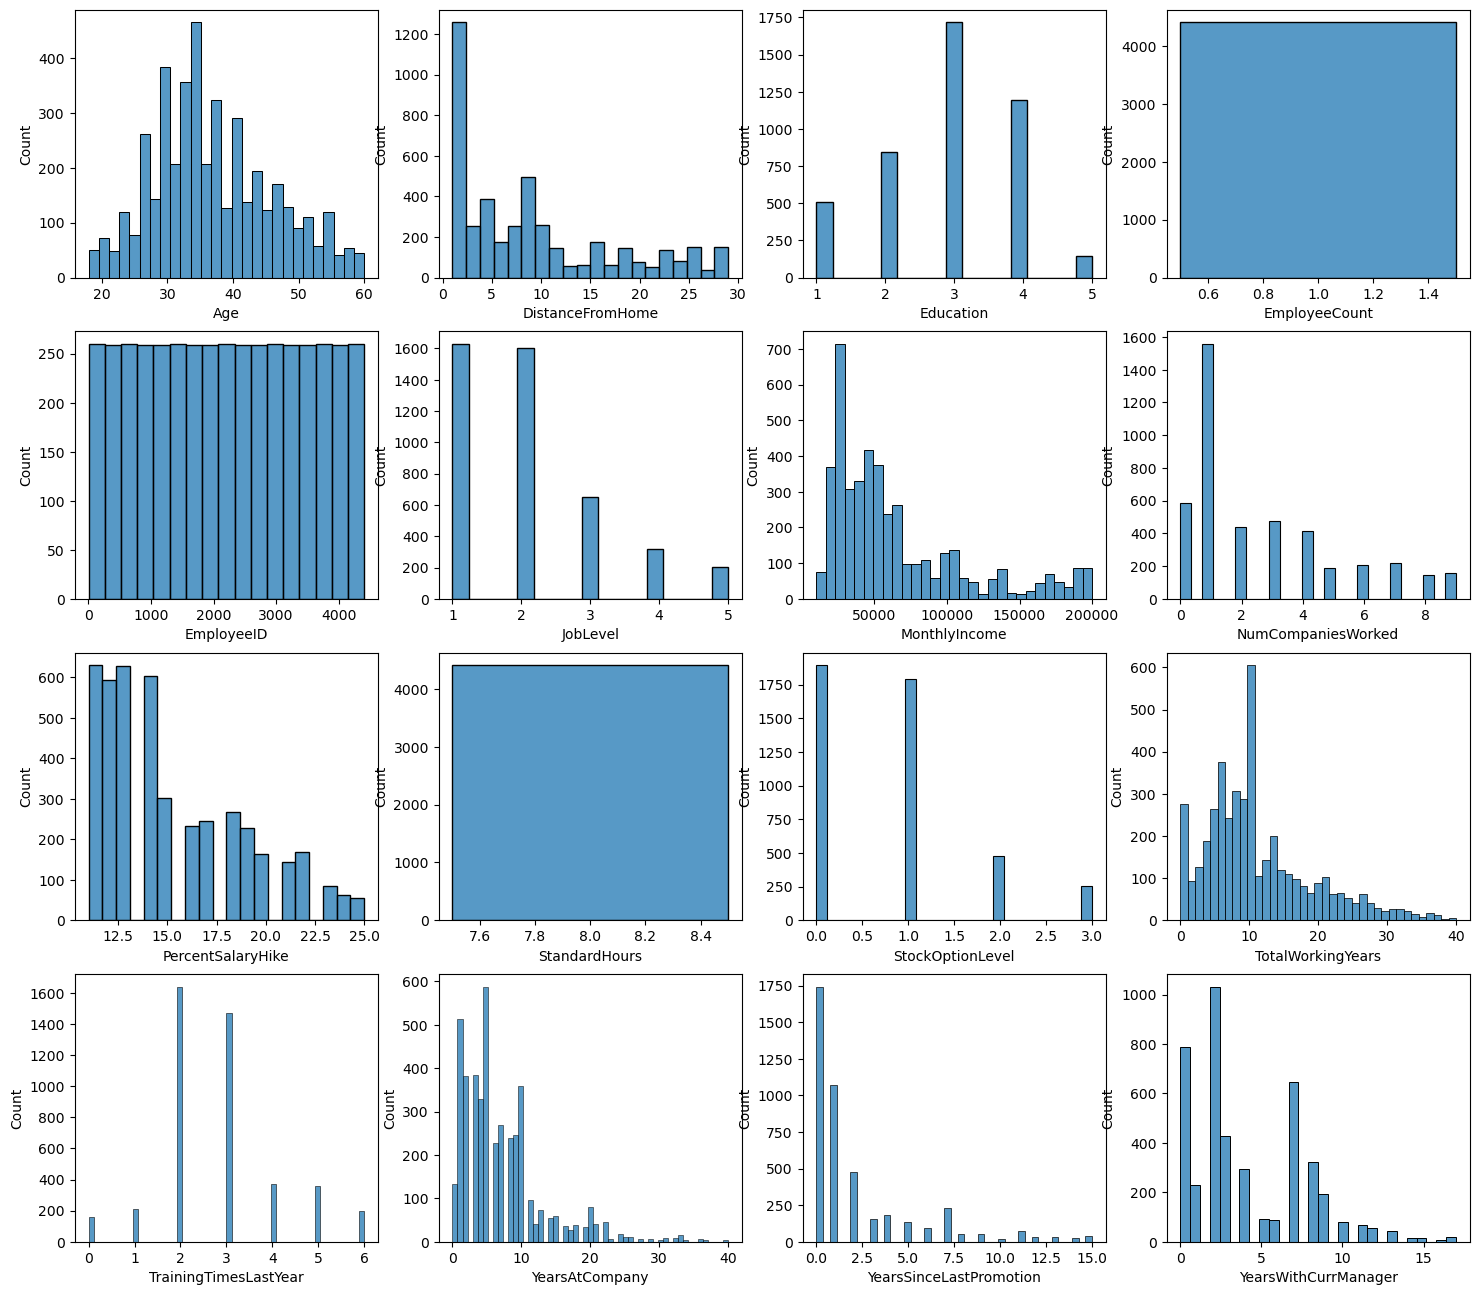

In [ ]:
# Generación de histogramas
fig, axes= plt.subplots(4, 4, figsize= (18, 16))
for i, column in enumerate(numeric_cols):
    sns.histplot(df[column], ax= axes[i//4, i%4], kde= False)

In [4]:
# Copia del dataframe para realizar cambios
df2= df.copy()

In [ ]:
# Distribución de variables
df2.nunique().sort_values(ascending= False)

EmployeeID                 4410
MonthlyIncome              1349
Age                          43
TotalWorkingYears            40
YearsAtCompany               37
DistanceFromHome             29
YearsWithCurrManager         18
YearsSinceLastPromotion      16
PercentSalaryHike            15
NumCompaniesWorked           10
JobRole                       9
TrainingTimesLastYear         7
EducationField                6
Education                     5
JobLevel                      5
StockOptionLevel              4
MaritalStatus                 3
BusinessTravel                3
Department                    3
Attrition                     2
Gender                        2
EmployeeCount                 1
Over18                        1
StandardHours                 1
dtype: int64

In [5]:
# Eliminamos las columnas constantes o con un solo valor y el ID
df2.drop(columns= ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID'], inplace= True)

In [ ]:
# Media de las variables con nulos
df2[['NumCompaniesWorked', 'TotalWorkingYears']].mean()

NumCompaniesWorked     2.694830
TotalWorkingYears     11.279936
dtype: float64

In [14]:
# Mediana de 'TotalWorkingYears'
df2['TotalWorkingYears'].median()

10.0

In [ ]:
# Distribución de la columna 'NumCompaniesWorked'
df2['NumCompaniesWorked'].value_counts()

NumCompaniesWorked
1.0    1558
0.0     586
3.0     474
2.0     438
4.0     415
7.0     222
6.0     208
5.0     187
9.0     156
8.0     147
Name: count, dtype: int64

In [ ]:
# Imputación de datos con la media al redondo de 'NumCompaniesWorked' 
df2['NumCompaniesWorked']= df2['NumCompaniesWorked'].fillna(3)

In [7]:
# Imputación de datos con la mediana de 'TotalWorkingYears'
df2['TotalWorkingYears']= df2['TotalWorkingYears'].fillna(10)

In [ ]:
# Hacemos de nuevo la comprobación de valores nulos
print(df2.isnull().sum().sum())

0


In [9]:
# Tipos de datos 
df2.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
PercentSalaryHike            int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
YearsWithCurrManager         int64
dtype: object

In [ ]:
# Cambio de tipo de dato de 'NumCompaniesWorked'
df2['NumCompaniesWorked']= df2['NumCompaniesWorked'].astype('int64')

In [ ]:
# Lista de columnas que no son numéricas, omitiendo la clase (la variable objetivo Attrition)
category_columns= list(set(df2.columns) - set(numeric_cols) - {'Attrition'})
category_columns

['MaritalStatus',
 'EducationField',
 'BusinessTravel',
 'Department',
 'Gender',
 'JobRole']

In [12]:
df2.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'Gender', 'JobLevel', 'JobRole',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

#### <span style="color:#4ea8de">Observaciones:</span>
- No se eliminan variables por correlación alta.
- Se eliminan variables constantes e innecesarias: 'EmployeeCount', 'StandardHours', 'Over18' y 'EmployeeID'.
- Se realiza la imputación de datos de la variable 'NumCompaniesWorked' con su media redondeada, al tratarse de un número entero.
- Se realiza la imputación de datos de la variable 'TotalWorkingYears' con la mediana.

<span style="color:#4ea8de">Agrupación o balanceo de variables</span>

In [ ]:
# Distribución en las columnas no numéricas
for column in category_columns:
    print('\n\n', df2[column].value_counts())



 BusinessTravel
Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: count, dtype: int64


 MaritalStatus
Married     2019
Single      1410
Divorced     981
Name: count, dtype: int64


 Department
Research & Development    2883
Sales                     1338
Human Resources            189
Name: count, dtype: int64


 Gender
Male      2646
Female    1764
Name: count, dtype: int64


 EducationField
Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: count, dtype: int64


 JobRole
Sales Executive              978
Research Scientist           876
Laboratory Technician        777
Manufacturing Director       435
Healthcare Representative    393
Manager                      306
Sales Representative         249
Research Director            240
Human Resources              156
Name: count, dtype: int64


In [14]:
# Proporción de variables que no cumplen el 5% del umbral de registros
category_columns2= []
for column in category_columns:
    i= df2[column].value_counts(normalize= True)    # Proporción de las variables
    if any( i < 0.05):                              
        category_columns2.append(i)                 # Almacena en la lista las variables menores a 5%

category_columns2


[Department
 Research & Development    0.653741
 Sales                     0.303401
 Human Resources           0.042857
 Name: proportion, dtype: float64,
 EducationField
 Life Sciences       0.412245
 Medical             0.315646
 Marketing           0.108163
 Technical Degree    0.089796
 Other               0.055782
 Human Resources     0.018367
 Name: proportion, dtype: float64,
 JobRole
 Sales Executive              0.221769
 Research Scientist           0.198639
 Laboratory Technician        0.176190
 Manufacturing Director       0.098639
 Healthcare Representative    0.089116
 Manager                      0.069388
 Sales Representative         0.056463
 Research Director            0.054422
 Human Resources              0.035374
 Name: proportion, dtype: float64]

In [ ]:
# Categorías que no cumplen con el umbral en las variables
for column in category_columns2:
    print('\n\n', column < 0.05)



 Department
Research & Development    False
Sales                     False
Human Resources            True
Name: proportion, dtype: bool


 EducationField
Life Sciences       False
Medical             False
Marketing           False
Technical Degree    False
Other               False
Human Resources      True
Name: proportion, dtype: bool


 JobRole
Sales Executive              False
Research Scientist           False
Laboratory Technician        False
Manufacturing Director       False
Healthcare Representative    False
Manager                      False
Sales Representative         False
Research Director            False
Human Resources               True
Name: proportion, dtype: bool


<span style="color:#4ea8de">Análisis bivariado</span>

In [ ]:
# Se realiza un análisis entre las variables anteriores para comprender su relación
df2.groupby(['Department', 'JobRole'])[['TotalWorkingYears']].mean().sort_values(by= 'TotalWorkingYears',ascending= False)

TotalWorkingYears
Department             JobRole                                     
Research & Development Manager                            12.739130
                       Laboratory Technician              12.280488
Sales                  Human Resources                    12.266667
Research & Development Human Resources                    12.000000
                       Sales Executive                    11.850794
Human Resources        Manufacturing Director             11.375000
Sales                  Laboratory Technician              11.337398
                       Manufacturing Director             11.325397
Research & Development Research Scientist                 11.228723
Sales                  Research Director                  11.222222
Human Resources        Research Scientist                 11.083333
Research & Development Manufacturing Director             11.073684
Sales                  Sales Executive                    11.030612
Research & Development Research Director                  10.974359
                       Healthcare Representative          10.931034
Human Resources        Laboratory Technician              10.538462
Sales                  Research Scientist                 10.510870
                       Manager                            10.500000
                       Sales Representative               10.368421
Human Resources        Sales Executive                    10.333333
Research & Development Sales Representative               10.150000
Sales                  Healthcare Representative           9.341463
Human Resources        Human Resources                     8.000000
                       Sales Representative                7.750000
                       Healthcare Representative           7.666667
                       Research Director                   7.000000
                       Manager                             6.333333

In [17]:
# JobRole y EducationField
df2.groupby(['JobRole', 'EducationField'])[['TotalWorkingYears']].mean().sort_values(by= 'TotalWorkingYears', ascending= False).sample(20)

,,TotalWorkingYears
JobRole,EducationField,
Sales Representative,Marketing,15.428571
Research Director,Human Resources,7.000000
Sales Executive,Medical,10.396226
Manager,Medical,12.233333
Sales Representative,Medical,10.933333
Sales Executive,Human Resources,6.800000
Manager,Life Sciences,10.782609
Manufacturing Director,Life Sciences,11.210256
Sales Executive,Marketing,11.638889


In [13]:
# Se elimina la columna 'Department'
df2.drop('Department', axis= 1, inplace= True)

In [14]:
# Agrupación de la categoría 'Human Resources' en las variables 'EducationField' y 'JobRole'
df2['EducationField']= df2['EducationField'].replace({'Other': 'Human Resources & Other', 'Human Resources': 'Human Resources & Other'})
df2['JobRole']= df2['JobRole'].replace({'Research Director': 'Research Director & Human Resources', 
                        'Human Resources': 'Research Director & Human Resources'})

In [15]:
# Volvemos a comprobar el balance de los datos
for column in df2[['JobRole', 'EducationField']]:
    print('\n\n', df2[column].value_counts(normalize= True) < 0.05)



 JobRole
Sales Executive                        False
Research Scientist                     False
Laboratory Technician                  False
Manufacturing Director                 False
Research Director & Human Resources    False
Healthcare Representative              False
Manager                                False
Sales Representative                   False
Name: proportion, dtype: bool


 EducationField
Life Sciences              False
Medical                    False
Marketing                  False
Technical Degree           False
Human Resources & Other    False
Name: proportion, dtype: bool


#### <span style="color:#4ea8de">Observaciones:</span>
- Se agrupan clases en las variables 'JobRole' y 'EducationField'.
- Se considera eliminar la variable 'Department' por repetir categorías.


In [16]:
# Visualizamos una muestra de las columnas no numéricas
df2.select_dtypes(include= ['object']).sample(3)

,Attrition,BusinessTravel,EducationField,Gender,JobRole,MaritalStatus
4118,No,Travel_Rarely,Medical,Male,Research Scientist,Single
2838,No,Travel_Rarely,Human Resources & Other,Female,Research Director & Human Resources,Married
2229,No,Travel_Rarely,Medical,Male,Sales Executive,Married


In [17]:
# Conversión de variables binarias 'Gender' y 'Attrition'
df2['Gender']= df2['Gender'].map({'Male': 1, 'Female': 0})
df2['Attrition']= df2['Attrition'].map({'Yes': 1, 'No': 0})

In [18]:
category_columns

['MaritalStatus',
 'EducationField',
 'BusinessTravel',
 'Department',
 'Gender',
 'JobRole']

In [19]:
# Se actualiza la lista category_columns eliminando 'Department' y 'Gender' que ha sido convertida a numérica
category_columns= set(category_columns) - {'Department', 'Gender'}
category_columns

{'BusinessTravel', 'EducationField', 'JobRole', 'MaritalStatus'}

In [20]:
# Conversión de variables categóricas
for column in category_columns:
    df2[column]= df2[column].astype('category')

In [21]:
# Comprobamos la conversión de tipos de datos
df2.dtypes

Age                           int64
Attrition                     int64
BusinessTravel             category
DistanceFromHome              int64
Education                     int64
EducationField             category
Gender                        int64
JobLevel                      int64
JobRole                    category
MaritalStatus              category
MonthlyIncome                 int64
NumCompaniesWorked            int64
PercentSalaryHike             int64
StockOptionLevel              int64
TotalWorkingYears           float64
TrainingTimesLastYear         int64
YearsAtCompany                int64
YearsSinceLastPromotion       int64
YearsWithCurrManager          int64
dtype: object

In [22]:
# Actualización de la lista de columnas numéricas
numeric_cols= df2.select_dtypes(exclude= 'category').columns
numeric_cols

Index(['Age', 'Attrition', 'DistanceFromHome', 'Education', 'Gender',
       'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

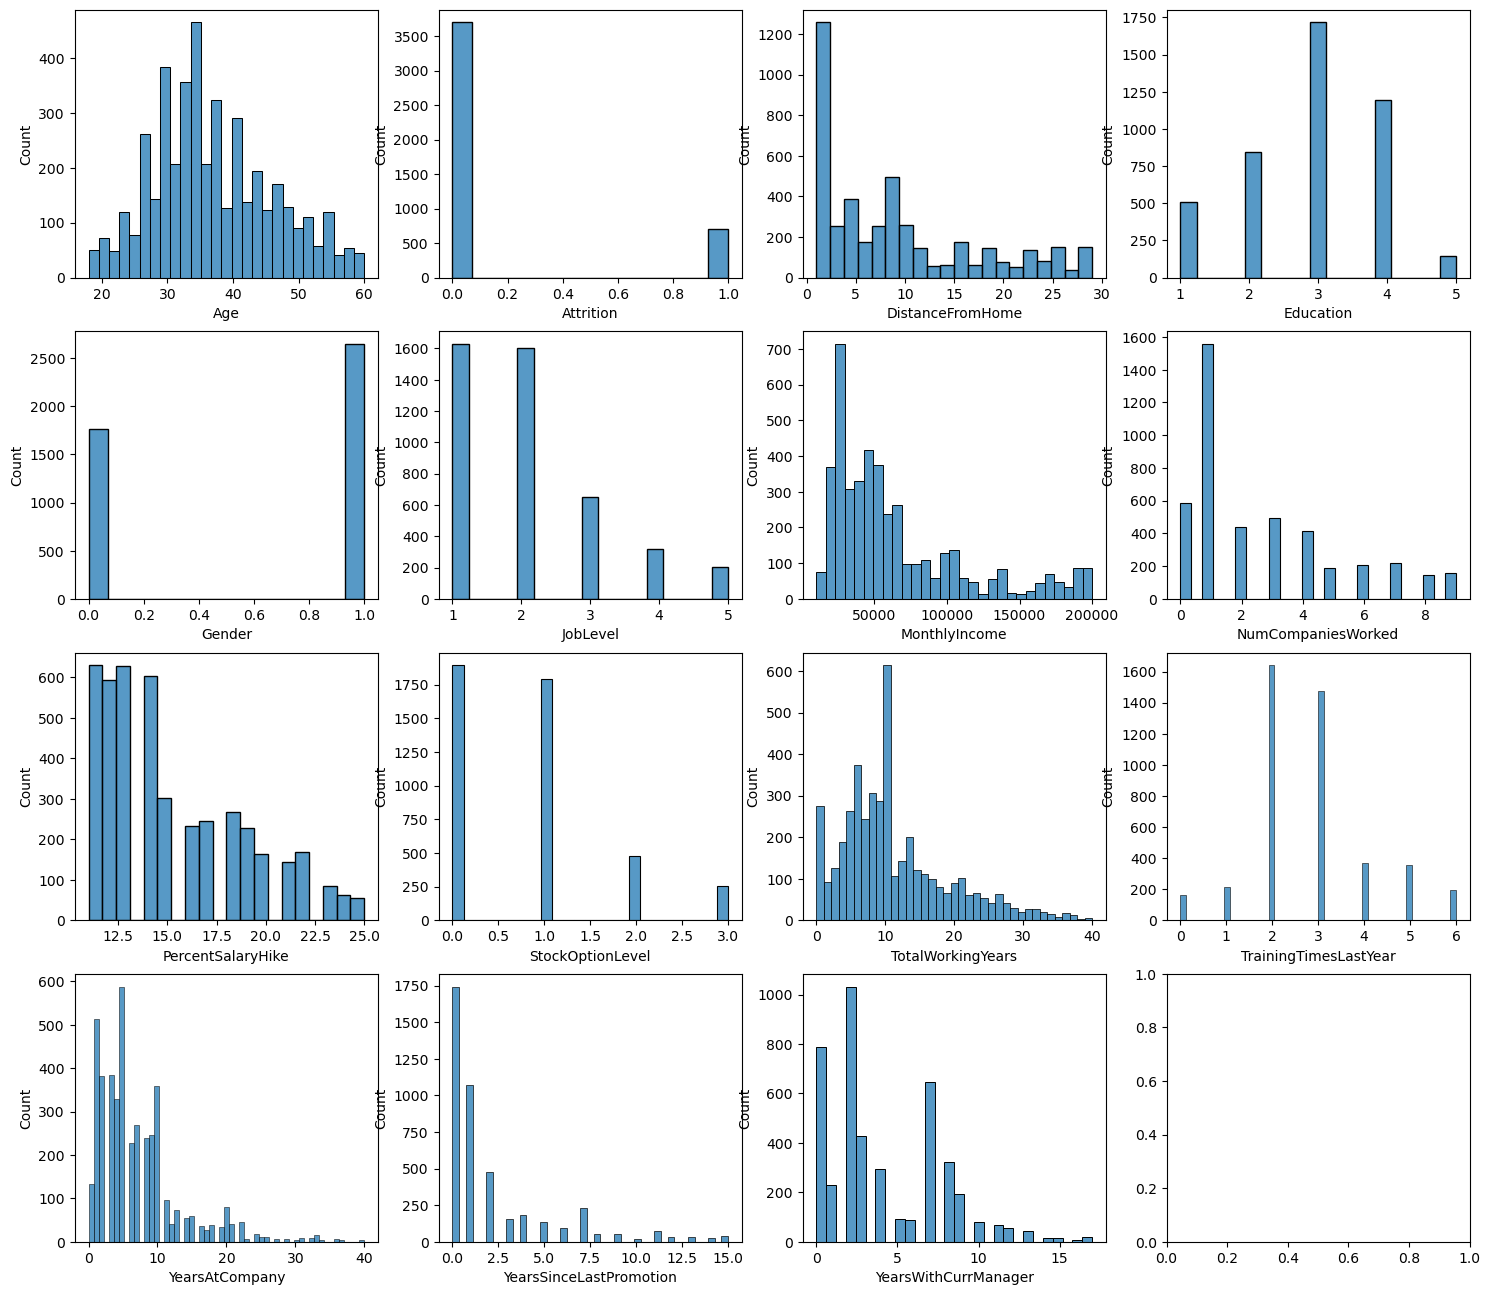

In [23]:
fig, axes= plt.subplots(4, 4, figsize= (18, 16))
for i, column in enumerate(numeric_cols):
    sns.histplot(df2[column], ax= axes[i//4, i%4], kde= False)

In [24]:
# Sesgos en el dataset
df2.skew(numeric_only= True)

Age                        0.413005
Attrition                  1.843111
DistanceFromHome           0.957466
Education                 -0.289484
Gender                    -0.408387
JobLevel                   1.024703
MonthlyIncome              1.368884
NumCompaniesWorked         1.027310
PercentSalaryHike          0.820569
StockOptionLevel           0.968321
TotalWorkingYears          1.118879
TrainingTimesLastYear      0.552748
YearsAtCompany             1.763328
YearsSinceLastPromotion    1.982939
YearsWithCurrManager       0.832884
dtype: float64

In [ ]:
# Tranformación logarítmica de las variables con sesgos en nuevas columnas
for column in ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']:
    df2[column + '_log']= np.log(df2[column] +1)

In [27]:
df2.head(3)

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome_log,TotalWorkingYears_log,YearsAtCompany_log,YearsSinceLastPromotion_log
0,51,0,Travel_Rarely,6,2,Life Sciences,0,1,Healthcare Representative,Married,...,0,1.0,6,1,0,0,11.784181,0.693147,0.693147,0.000000
1,31,1,Travel_Frequently,10,1,Life Sciences,0,1,Research Scientist,Single,...,1,6.0,3,5,1,4,10.642826,1.945910,1.791759,0.693147
2,32,0,Travel_Frequently,17,4,Human Resources & Other,1,4,Sales Executive,Married,...,3,5.0,2,5,0,3,12.171900,1.791759,1.791759,0.000000


In [28]:
# Importación de librería para estandarización de variables
from sklearn.preprocessing import StandardScaler

In [29]:
# Creación de objeto Scaler para estandarizar las variables que han sido transformadas logarítmicamente
scaler= StandardScaler()
df2[['MonthlyIncome_log', 'TotalWorkingYears_log', 
     'YearsAtCompany_log', 'YearsSinceLastPromotion_log']]= scaler.fit_transform(df2[['MonthlyIncome_log', 'TotalWorkingYears_log', 
                                                                                        'YearsAtCompany_log', 'YearsSinceLastPromotion_log']])

#### <span style="color:#4ea8de">Observaciones:</span>
- Se realiza la transformación logarítmica y estandarización de variables con sesgos (skew mayor a 1).
- Se consideró a las variables 'JobLevel'y 'NumCompaniesWorked' como discretas (por contener pocos valores) por lo que no pueden tener sesgos.
- Se realizó la conversión a numéricos o binarios de las variables 'Attrition' y 'Gender'.

In [30]:
df2.head(3)

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,MonthlyIncome_log,TotalWorkingYears_log,YearsAtCompany_log,YearsSinceLastPromotion_log
0,51,0,Travel_Rarely,6,2,Life Sciences,0,1,Healthcare Representative,Married,...,0,1.0,6,1,0,0,1.398738,-2.294803,-1.478408,-0.973342
1,31,1,Travel_Frequently,10,1,Life Sciences,0,1,Research Scientist,Single,...,1,6.0,3,5,1,4,-0.319624,-0.499422,-0.026394,-0.117271
2,32,0,Travel_Frequently,17,4,Human Resources & Other,1,4,Sales Executive,Married,...,3,5.0,2,5,0,3,1.982468,-0.720341,-0.026394,-0.973342


In [31]:
# Sesgo en las variables estandarizadas
df2[['MonthlyIncome_log', 'TotalWorkingYears_log', 
     'YearsAtCompany_log', 'YearsSinceLastPromotion_log']].skew(numeric_only= True)

MonthlyIncome_log              0.286023
TotalWorkingYears_log         -0.621988
YearsAtCompany_log            -0.207567
YearsSinceLastPromotion_log    0.718315
dtype: float64

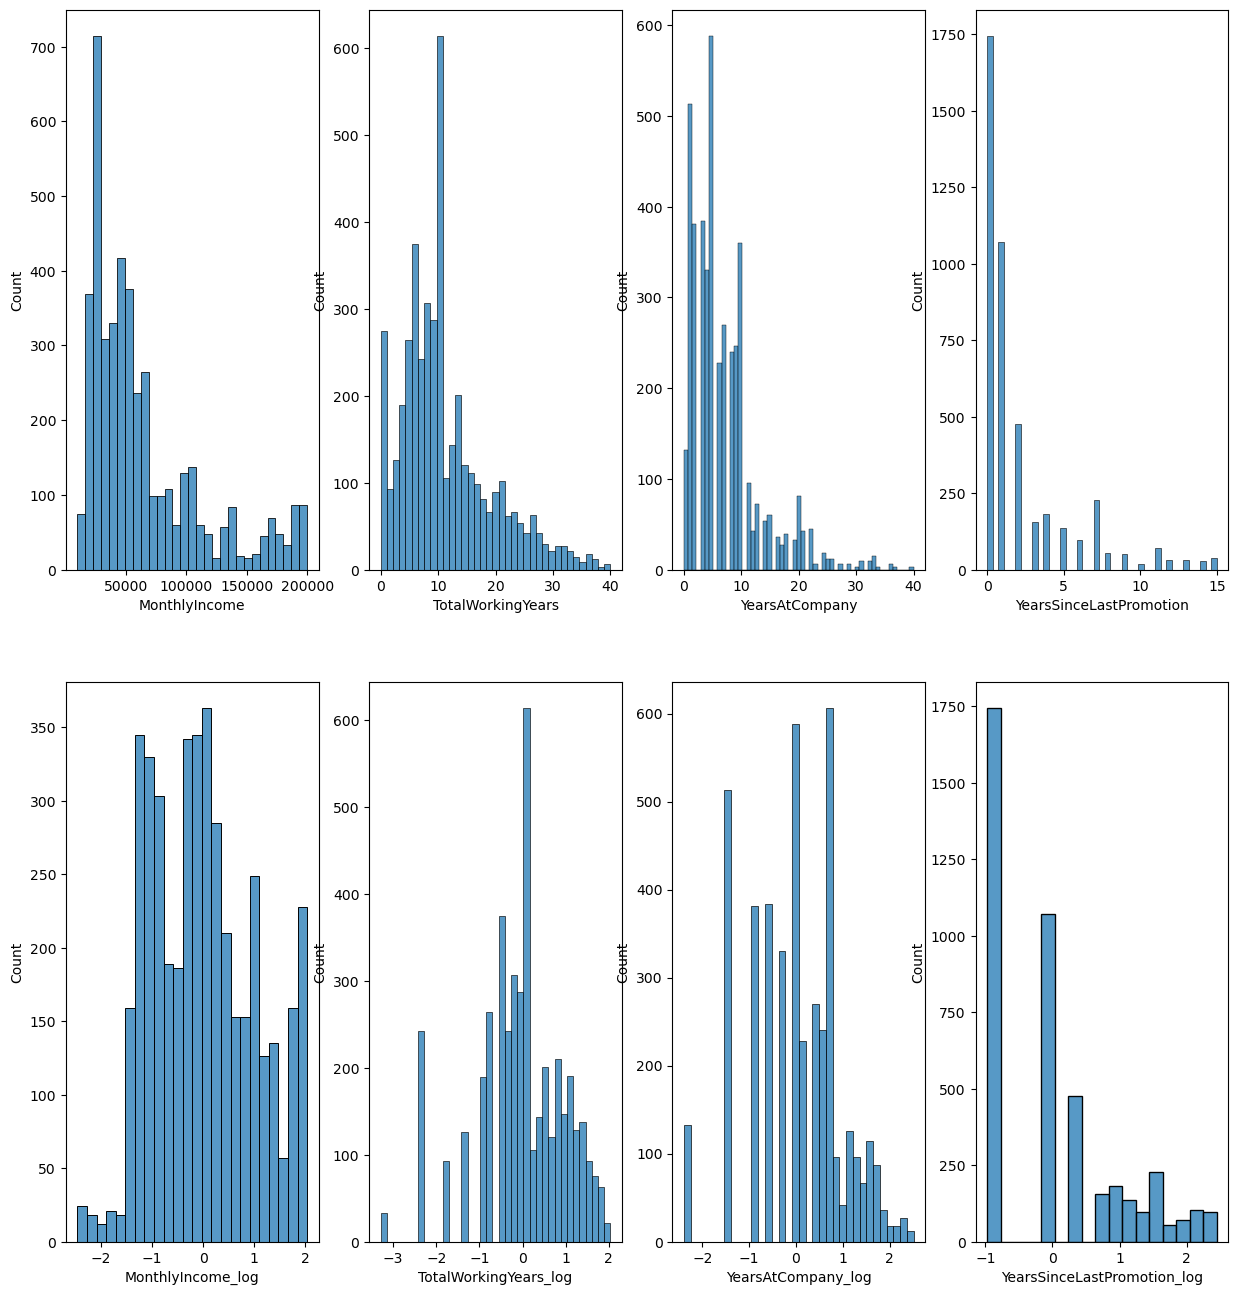

In [39]:
# Comparación de histogramas de variables con sesgos vs variables transformadas logarítmicamente y estandarizadas
fig, axes= plt.subplots(2, 4, figsize= (15, 16))
for i, column in enumerate(['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion',
    'MonthlyIncome_log', 'TotalWorkingYears_log', 'YearsAtCompany_log', 'YearsSinceLastPromotion_log']):
    sns.histplot(df2[column], ax= axes[i//4, i%4], kde= False)

### <span style="color:#4ea8de">Split de dataset (70:30)</span>

In [47]:
# Importación de librerías para realizar el split de dataset y regresión lineal
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [33]:
category_columns

{'BusinessTravel', 'EducationField', 'JobRole', 'MaritalStatus'}

In [ ]:

X= df2.drop(['Attrition'], axis= 1) # Variables independientes
y= df2['Attrition'] # Clase o variable dependiente

X= pd.get_dummies(X, columns= ['BusinessTravel', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first= True, dtype= int) # Conversión de las variables categóricas a dummies
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.30, random_state= 1) # Variables de entrenamiento y prueba


In [50]:
X.head(3)

,Age,DistanceFromHome,Education,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,...,EducationField_Technical Degree,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director & Human Resources,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,51,6,2,0,1,131160,1,11,0,1.0,...,0,0,0,0,0,0,0,0,1,0
1,31,10,1,0,1,41890,0,23,1,6.0,...,0,0,0,0,0,1,0,0,0,1
2,32,17,4,1,4,193280,1,15,3,5.0,...,0,0,0,0,0,0,1,0,1,0


In [51]:
y.head(3)

0    0
1    1
2    0
Name: Attrition, dtype: int64

In [52]:
# Logitud de los datasets
print('{0:0.2f}% de datos reservados para entrenar'.format((len(X_train)/len(df.index)) * 100))
print('{0:0.2f}% de datos reservados para evaluar'.format((len(X_test)/len(df.index)) * 100))

70.00% de datos reservados para entrenar
30.00% de datos reservados para evaluar


### <span style="color:#4ea8de">Regresión lineal a la variable Attrition</span>

In [ ]:
# Definición del modelo de regresión logística con el parámetro class_weight balanceado
model= LogisticRegression(solver='liblinear', class_weight= 'balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [68]:
# Intercepto
print('Intercepto: ', model.intercept_)

Intercepto:  [-0.19961251]


In [64]:
# Coeficientes de la ecuación
coef_df= pd.DataFrame(model.coef_)

In [ ]:
# A las columnas del dataframe se les asignan los nombres de las variables independientes
coef_df.columns= X.columns

In [ ]:
# Trasposición del dataframe
coeff= coef_df.T

In [88]:
coeff

,0
Age,-0.029984
DistanceFromHome,0.004914
Education,-0.064730
Gender,0.063515
JobLevel,-0.060187
MonthlyIncome,-0.000002
NumCompaniesWorked,0.149954
PercentSalaryHike,0.004410
StockOptionLevel,-0.033380
TotalWorkingYears,-0.007674


<span style="color:#4ea8de">Predicción</span>

In [70]:
# Variable que almacena la predicción de la prueba
y_predict= model.predict(X_test)

In [ ]:
# Comparación del Attrition real y las predicciones
preds_df= X_test.copy()
preds_df['Attrition real']= y_test
preds_df['Attrition predicción']= y_predict
preds_df[['Attrition real', 'Attrition predicción']].head(20)


,Attrition real,Attrition predicción
2016,0,0
4118,0,1
219,0,1
4402,1,1
787,0,0
200,0,0
2539,0,0
3744,0,1
1891,0,0
3963,1,1


In [93]:
# Orden de importancia de variables por coeficiente
coeff.sort_values(by= 0, ascending= False)

,0
BusinessTravel_Travel_Frequently,1.108042
MaritalStatus_Single,1.044425
BusinessTravel_Travel_Rarely,0.484215
JobRole_Research Director & Human Resources,0.293930
JobRole_Research Scientist,0.263213
JobRole_Sales Executive,0.237521
JobRole_Sales Representative,0.235665
JobRole_Laboratory Technician,0.230924
MaritalStatus_Married,0.181016
NumCompaniesWorked,0.149954


<span style="color:#4ea8de">Evaluación</span>

In [ ]:
# Importación de métricas para evaluar el modelo
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

In [111]:
model_1= accuracy_score(y_test, y_predict)
recall_1= recall_score(y_test, y_predict)
precision_1= precision_score(y_test, y_predict)
f1_1= f1_score(y_test, y_predict)

In [112]:
roc_auc_1= roc_auc_score(y_test, y_predict)

In [118]:
print('Medidas del modelo: \n')
print('Accuracy = {0:0.2f}'.format(model_1))
print('Recall = {0:0.2f}'.format(recall_1))
print('F1 Score = {0:0.2f}'.format(f1_1))
print('Precision = {0:0.2f}'.format(precision_1))
print('ROC AUC Score = {0:0.2f}'.format(roc_auc_1))

Medidas del modelo: 

Accuracy = 0.67
Recall = 0.67
F1 Score = 0.41
Precision = 0.29
ROC AUC Score = 0.67


In [ ]:
# Definición del modelo sin el parámetro class_weight (sin balanceo de clases)
model2= LogisticRegression(solver='liblinear')
model2.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [116]:
y_predict2= model2.predict(X_test)

In [117]:
model_2= accuracy_score(y_test, y_predict2)
recall_2= recall_score(y_test, y_predict2)
precision_2= precision_score(y_test, y_predict2)
f1_2= f1_score(y_test, y_predict2)
roc_2= roc_auc_score(y_test, y_predict2)

c:\Users\einzw\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [119]:
print('Medidas del modelo sin balancear clases: \n')
print('Accuracy = {0:0.2f}'.format(model_2))
print('Recall = {0:0.2f}'.format(recall_2))
print('F1 Score = {0:0.2f}'.format(f1_2))
print('Precision = {0:0.2f}'.format(precision_2))
print('ROC AUC Score = {0:0.2f}'.format(roc_2))

Medidas del modelo sin balancear clases: 

Accuracy = 0.83
Recall = 0.00
F1 Score = 0.00
Precision = 0.00
ROC AUC Score = 0.50


#### <span style="color:#4ea8de">Conclusiones del modelo:</span>
- <b>Accuracy:</b> El modelo predijo al 67%
- <b>Recall:</b> El modelo detectó en un 67% los positivos reales (Los empleados que se fueron).
- <b>Precision:</b> EL 29% de los empleados que el modelo predijo como positivos reales realmente se fueron.
- <b>F1:</b> El equilibrio entre Recall y Precision es de 41%. 
- <b>Área bajo la curva ROC:</b> El desempeño del modelo para distinguir entre positivos y negativos está por encima del azar, pero limitado.
<br><br>
- Las <b>variables</b> con los coeficientes de mayor peso son BusinessTravel_Travel_Frequently y MaritalStatus_Single <b>(Personas con viajes de negocios constante y personas solteras)</b>.
<br><br>
- Al ajustar internamente el modelo con el <b>balance de clases</b> hay una gran variación en las métricas.

### <span style="color:#4ea8de">Matriz de confusión</span>

In [120]:
# Importación de librerías para crear la matriz
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Generación de la matriz de confusión
cm= confusion_matrix(y_test, y_predict)
cm

array([[742, 358],
       [ 74, 149]])

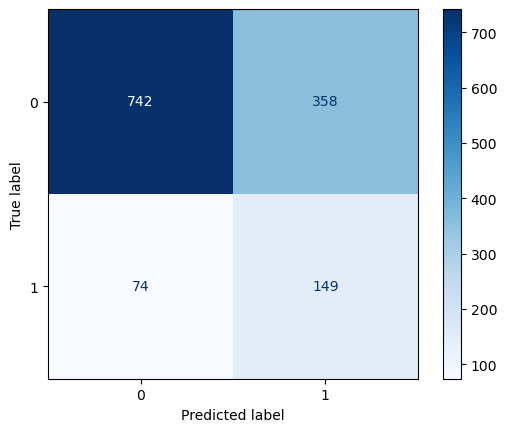

In [122]:
# Visualización gráfica de la matriz de confusión (regresión logística con clase balanceada)
df_cm= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= model.classes_)
df_cm.plot(cmap= plt.cm.Blues)
plt.show()

#### <span style="color:#4ea8de">Conclusiones de la matriz de confusión:</span>
- Verdaderos negativos (TN) y verdaderos positivos (TP):<br>
 <b>742 empleados permanecen y 149 empleados se van.</b>
 <br><br>
- Falsos positivos (FP) y Falsos negativos (FN): <br>
<b>358 empleados permanecen (que el modelo predijo erróneamente como empleados que abandonan), 74 empleados que sí abandonan (que el modelo no detectó).</b>
